# Benchmarki

# Symulowana Bifurkacja

## Implementacja CPU

Tworzenie wykresu dla discrete_simulated_bifurcation_gpu: 100%|██████████| 10/10 [00:12<00:00,  1.22s/it]
Tworzenie wykresu dla discrete_simulated_bifurcation_gpu_naive: 100%|██████████| 10/10 [01:03<00:00,  6.36s/it]


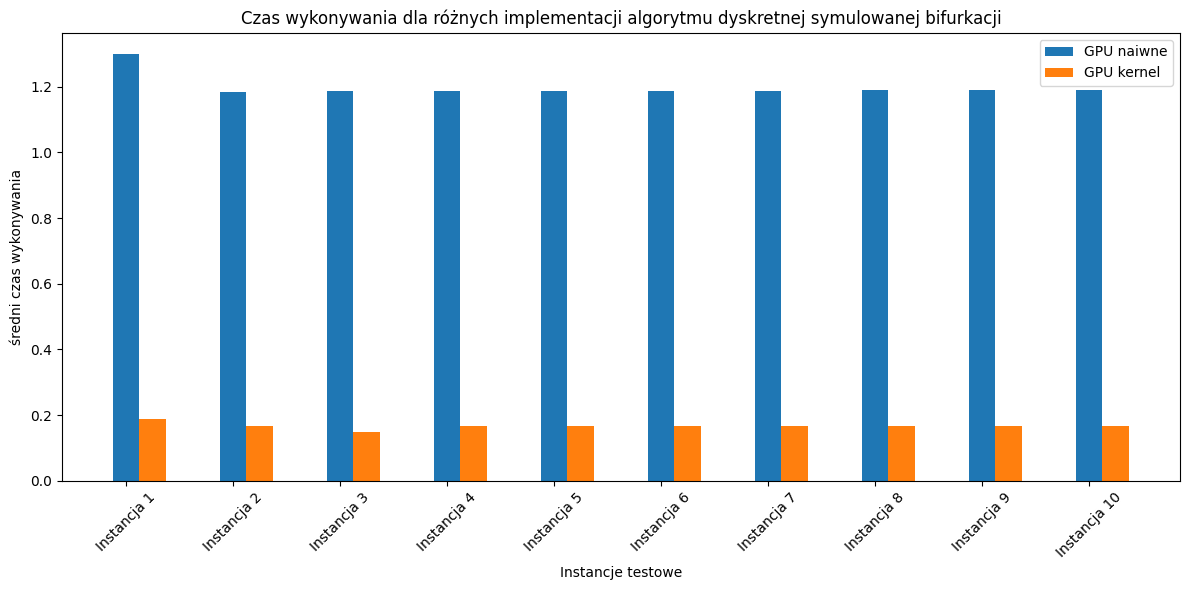

In [ ]:
import torch
import time

import simulated_bifurcation as sb
import cupy as cp
import matplotlib.pyplot as plt
import numpy as np

from funkcje_pomocnicze import read_instance, pegasus_benchmark
from benchmarks import discrete_simulated_bifurcation_gpu, discrete_simulated_bifurcation, discrete_simulated_bifurcation_gpu_naive
from IPython.utils.io import capture_output
from tqdm import tqdm


functions = [discrete_simulated_bifurcation_gpu, discrete_simulated_bifurcation_gpu_naive]

global_results = []
for function in functions:
    results_mean = []
    times_mean = []
    for instance in tqdm(pegasus_benchmark, desc=f"Tworzenie wykresu dla {function.__name__}"):
        J, h = read_instance(instance.path, convention="minus_half")
        J2 = cp.asarray(J, dtype=cp.float32)
        h2 = cp.asarray(h, dtype=cp.float32)

        results = []
        times = []

        for _ in range(5):
    
            start = time.time()  
            with capture_output() as captured:
                states, energies = function(J2, h2, 1000, 0.25, 2**11)
            end = time.time()
            results.append(instance.best_energy - min(energies).item())      
            times.append(end - start) 

        results_mean.append(np.mean(np.array(results)))
        times_mean.append(np.mean(np.array(times)))
    global_results.append(times_mean)


instancje = [f"Instancja {i}" for i in range(1, 11)]

x = np.arange(len(instancje))
width = 0.25  

fig, ax = plt.subplots(figsize=(12, 6))

rects2 = ax.bar(x, global_results[1], width, label='GPU naiwne')
rects3 = ax.bar(x + width, global_results[0], width, label='GPU kernel')

ax.set_xlabel('Instancje testowe')
ax.set_ylabel('Średni czas wykonywania [s]')
ax.set_title('Czas wykonywania dla różnych implementacji algorytmu dyskretnej symulowanej bifurkacji')
ax.set_xticks(x)
ax.set_xticklabels(instancje, rotation=45)
ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
import torch
import simulated_bifurcation as sb
import numpy as np
from funkcje_pomocnicze import read_instance, pegasus_benchmark, test_pegasus, ising_to_qubo, small_pegasus
from benchmarks import discrete_simulated_bifurcation

J, h = read_instance(small_pegasus.path, convention="minus_half")
J1, h1 = read_instance(small_pegasus.path, convention="dwave")

J1 = torch.tensor(J1, dtype=torch.float32)
h1 = torch.tensor(h1, dtype=torch.float32)




states, energies = discrete_simulated_bifurcation(J, h, 200, 0.25, 2**9)
print(min(energies))
sb.minimize(J1, h1, domain="spin", dtype=torch.float32)

Symulowana Bifurkacja: 100%|██████████| 200/200 [00:01<00:00, 120.10it/s]


-39.0


🏁 Bifurcated agents: 100%|██████████| 128/128 [00:00<00:00, 455.58 agents/s]


(tensor([-1., -1., -1., -1.,  1.,  1.,  1.,  1.,  1., -1., -1., -1.,  1., -1.,
          1.,  1., -1.,  1.,  1.,  1.,  1.,  1., -1.,  1.]),
 tensor(-33.))

## Implementacja GPU

In [ ]:
import torch
import simulated_bifurcation as sb
import cupy as cp
from funkcje_pomocnicze import read_instance,  pegasus_benchmark
from benchmarks import discrete_simulated_bifurcation_gpu
from IPython.utils.io import capture_output

for instance in pegasus_benchmark:
    J, h = read_instance(instance.path, convention="minus_half")
    J2 = cp.asarray(J, dtype=cp.float32)
    h2 = cp.asarray(h, dtype=cp.float32)
    
    with capture_output() as captured:
        states, energies = discrete_simulated_bifurcation_gpu(J2, h2, 1000, 0.25, 2**11)

    print(min(energies))
    print(instance.best_energy)

# Brute Force